In [89]:
!pip install xgboost

In [90]:
from functools import reduce

# --- PySpark ML และ Spark Libraries ---
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, Imputer
from pyspark.ml.evaluation import RegressionEvaluator
# 💡 แก้ไข Typo: SparkXGBRegresso -> SparkXGBRegressor
from xgboost.spark import SparkXGBRegressor 

# --- PySpark Types ---
from pyspark.sql.types import (
    ArrayType, StringType, StructType, StructField, 
    IntegerType, FloatType
)

# --- PySpark Functions (รวมฟังก์ชันทั้งหมด) ---
from pyspark.sql.functions import (
    col, trim, lower, regexp_replace, sum, udf, 
    to_timestamp, split, datediff, substring, length,
    current_timestamp, when, try_to_timestamp, to_date, 
    encode, decode, count, avg, min, max, lit, round
)

# --- External Libraries ---
from pythainlp import word_tokenize
from pythainlp.corpus import thai_stopwords

In [91]:
spark_url = 'local'
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, FloatType

spark = SparkSession.builder \
    .appName("XGBoostCondoPriceModel") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .master("local[*]") \
    .getOrCreate()

In [92]:
sc = spark.sparkContext

# Path เดียวกันกับที่คุณใช้ในการบันทึก
OUTPUT_PATH_SUBSET = "file:///E:/2_1/ds/project/predicted_output_lgb.csv"

df_ser = spark.read.csv(
    OUTPUT_PATH_SUBSET, 
    header=True,
    encoding="UTF-8",
    # 💡 เพิ่ม inferSchema=True
    inferSchema=True 
)



In [93]:
# df_processedd = df_processed.drop("address", "lat","lon","comment_clean","timestamp_dt","last_activity_dt","year_reported","year_last_activity")
df_ser.printSchema() # ตรวจสอบอีกครั้ง
print(df_ser.count())

root
 |-- ticket_id: string (nullable = true)
 |-- severity_score: double (nullable = true)

100379


In [94]:
OUTPUT_PATH = "file:///E:/2_1/ds/project/output_csv"

# อ่านไฟล์ที่บันทึกไว้กลับเข้ามา
df_processed = spark.read.csv(
    OUTPUT_PATH, 
    header=True,
    # ต้องระบุ encoding อีกครั้ง!
    encoding="UTF-8" 
)

print(f"Schema หลังโหลดข้อมูลใหม่:{df_processed.count()}")
df_processed.printSchema()


Schema หลังโหลดข้อมูลใหม่:100379
root
 |-- ticket_id: string (nullable = true)
 |-- address: string (nullable = true)
 |-- district: string (nullable = true)
 |-- lat: string (nullable = true)
 |-- lon: string (nullable = true)
 |-- DaysActive_Pending: string (nullable = true)
 |-- comment_clean: string (nullable = true)
 |-- timestamp_dt: string (nullable = true)
 |-- last_activity_dt: string (nullable = true)
 |-- type_ถนน: string (nullable = true)
 |-- type_ทางเท้า: string (nullable = true)
 |-- type_ความปลอดภัย: string (nullable = true)
 |-- type_แสงสว่าง: string (nullable = true)
 |-- type_ความสะอาด: string (nullable = true)
 |-- type_กีดขวาง: string (nullable = true)
 |-- type_ท่อระบายน้ำ: string (nullable = true)
 |-- type_น้ำท่วม: string (nullable = true)
 |-- type_ต้นไม้: string (nullable = true)
 |-- type_PM25: string (nullable = true)
 |-- type_จราจร: string (nullable = true)
 |-- type_สะพาน: string (nullable = true)
 |-- year_reported: string (nullable = true)
 |-- year_las

In [95]:

CONDO_FILE_PATH = "ddproperty_processed.csv" 
# โปรดเปลี่ยนเป็น path จริงหากคุณไม่ได้อัปโหลดไฟล์ผ่านเครื่องมือ

df_condo_raw = spark.read.csv(
    CONDO_FILE_PATH,
    header=True,
    encoding="UTF-8",
    inferSchema=True  # ให้ Spark ลองเดาประเภทข้อมูล
)


df_condo_raw.printSchema()

root
 |-- url: string (nullable = true)
 |-- title: string (nullable = true)
 |-- publish_date: date (nullable = true)
 |-- price: double (nullable = true)
 |-- price_per_sqm: double (nullable = true)
 |-- usable_area: double (nullable = true)
 |-- bedroom: double (nullable = true)
 |-- restroom: double (nullable = true)
 |-- coords: string (nullable = true)
 |-- full_address: string (nullable = true)
 |-- sub_district: string (nullable = true)
 |-- district: string (nullable = true)
 |-- province: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)



In [96]:

df_current = df_processed 

# 1. กำหนดคอลัมน์ที่ต้องแปลง
float_cols = ["lat", "lon", "DaysActive_Pending"]
int_cols = [
    "type_ถนน", "type_ทางเท้า", "type_ความปลอดภัย", "type_แสงสว่าง", 
    "type_ความสะอาด", "type_กีดขวาง", "type_ท่อระบายน้ำ", "type_น้ำท่วม", 
    "type_ต้นไม้", "type_PM25", "type_จราจร", "type_สะพาน",
    "year_reported", "year_last_activity"
]

# 2. แปลงคอลัมน์ Float และ Integer
for c in float_cols:
    df_current = df_current.withColumn(c, col(c).cast("float"))

for c in int_cols:
    df_current = df_current.withColumn(c, col(c).cast("int"))



df_ml_ready = df_current.drop("timestamp_dt", "last_activity_dt","address","comment_clean","year_reported","year_last_activity","lat","lon")

print("Columns timestamp_dt and last_activity_dt have been dropped.")

# ตรวจสอบ Schema ใหม่
print("The updated schema is:")
df_ml_ready.printSchema()

Columns timestamp_dt and last_activity_dt have been dropped.
The updated schema is:
root
 |-- ticket_id: string (nullable = true)
 |-- district: string (nullable = true)
 |-- DaysActive_Pending: float (nullable = true)
 |-- type_ถนน: integer (nullable = true)
 |-- type_ทางเท้า: integer (nullable = true)
 |-- type_ความปลอดภัย: integer (nullable = true)
 |-- type_แสงสว่าง: integer (nullable = true)
 |-- type_ความสะอาด: integer (nullable = true)
 |-- type_กีดขวาง: integer (nullable = true)
 |-- type_ท่อระบายน้ำ: integer (nullable = true)
 |-- type_น้ำท่วม: integer (nullable = true)
 |-- type_ต้นไม้: integer (nullable = true)
 |-- type_PM25: integer (nullable = true)
 |-- type_จราจร: integer (nullable = true)
 |-- type_สะพาน: integer (nullable = true)



In [97]:


# (Optional) ถ้ามีค่าซ้ำ ให้ตัดทิ้งก่อน Join เพื่อความปลอดภัย
df_severity = df_ser.dropDuplicates(["ticket_id"])

print("--- ข้อมูล Severity Score ---")
df_severity.show(5)

# ==========================================
# 2. ทำการ Join กับ df_ml_ready
# ==========================================

# ใช้ Left Join เพื่อรักษาข้อมูลใน df_ml_ready ไว้ทั้งหมด
# (แม้ว่า Ticket นั้นจะไม่มีคะแนน severity ก็ตาม)
df_final_dataset = df_ml_ready.join(
    df_severity,
    on="ticket_id",
    how="left"
)

print("--- ผลลัพธ์หลัง Join ---")
df_final_dataset.printSchema()
df_final_dataset.select("ticket_id", "district", "severity_score").show(5)

--- ข้อมูล Severity Score ---
+-----------+------------------+
|  ticket_id|    severity_score|
+-----------+------------------+
|2024-H6TG99|51.741197660062866|
|     G3JXAN| 80.87304761904763|
|     BVUW96| 86.83966666666666|
|     LAYX4A| 72.62933333333335|
|     3V377M| 79.44333333333334|
+-----------+------------------+
only showing top 5 rows
--- ผลลัพธ์หลัง Join ---
root
 |-- ticket_id: string (nullable = true)
 |-- district: string (nullable = true)
 |-- DaysActive_Pending: float (nullable = true)
 |-- type_ถนน: integer (nullable = true)
 |-- type_ทางเท้า: integer (nullable = true)
 |-- type_ความปลอดภัย: integer (nullable = true)
 |-- type_แสงสว่าง: integer (nullable = true)
 |-- type_ความสะอาด: integer (nullable = true)
 |-- type_กีดขวาง: integer (nullable = true)
 |-- type_ท่อระบายน้ำ: integer (nullable = true)
 |-- type_น้ำท่วม: integer (nullable = true)
 |-- type_ต้นไม้: integer (nullable = true)
 |-- type_PM25: integer (nullable = true)
 |-- type_จราจร: integer (nullable =

In [98]:
from pyspark.sql.functions import col, trim, regexp_replace, count

# รายชื่อ 50 เขตอย่างเป็นทางการของกรุงเทพมหานคร
BANGKOK_50_DISTRICTS = [
    "คลองสาน", "คลองสามวา", "คลองเตย", "คันนายาว", "จตุจักร", "จอมทอง", 
    "ดอนเมือง", "ดินแดง", "ดุสิต", "ตลิ่งชัน", "ทวีวัฒนา", "ทุ่งครุ", 
    "ธนบุรี", "บางกอกน้อย", "บางกอกใหญ่", "บางกะปิ", "บางขุนเทียน", 
    "บางคอแหลม", "บางซื่อ", "บางนา", "บางบอน", "บางพลัด", "บางรัก", 
    "บางเขน", "บางแค", "บึงกุ่ม", "ปทุมวัน", "ประเวศ", "ป้อมปราบศัตรูพ่าย", 
    "พญาไท", "พระนคร", "พระโขนง", "ภาษีเจริญ", "มีนบุรี", "ยานนาวา", 
    "ราชเทวี", "ราษฎร์บูรณะ", "ลาดกระบัง", "ลาดพร้าว", "วังทองหลาง", 
    "วัฒนา", "สวนหลวง", "สะพานสูง", "สัมพันธวงศ์", "สาทร", "สายไหม", 
    "หนองจอก", "หนองแขม", "หลักสี่", "ห้วยขวาง"
]
# ใช้ DataFrame ข้อมูล Ticket ที่คุณใช้ในการคำนวณ Livability Score (df_ml_ready)

# 1. ทำความสะอาดอย่างเข้มงวดที่สุด
df_cleaned = df_final_dataset.withColumn("district_cleaned", col("district"))

# ลบอักขระที่มองไม่เห็นทั้งหมด (Non-printable/control characters)
# เช่น \u200b, \u0000, \u0001, ฯลฯ
df_cleaned = df_cleaned.withColumn(
    "district_cleaned",
    regexp_replace(col("district_cleaned"), "[\\p{C}]", "") 
)


# แก้ไข Typo และลบช่องว่างหลายช่องให้เหลือช่องว่างเดียว
df_cleaned = df_cleaned.withColumn(
    "district_cleaned",
    regexp_replace(col("district_cleaned"), "ป้อมปราบศัตรูพ่า", "ป้อมปราบศัตรูพ่าย")
)
df_cleaned = df_cleaned.withColumn(
    "district_cleaned", 
    regexp_replace(col("district_cleaned"), "ป้อมปราบศัตรูพ่ายย", "ป้อมปราบศัตรูพ่าย") # 💡 แก้ไข Typo ใหม่
)
df_cleaned = df_cleaned.withColumn(
    "district_cleaned",
    regexp_replace(col("district_cleaned"), "\\s+", " ")
)

# Trim สุดท้ายเพื่อลบช่องว่างหัวท้ายที่อาจหลงเหลือ
df_cleaned = df_cleaned.withColumn(
    "district_cleaned",
    trim(col("district_cleaned"))
)

# 2. ใช้ district_cleaned แทน district เดิม
df_ml_ready_filtered = df_cleaned.drop("district") \
                                 .withColumnRenamed("district_cleaned", "district")

# 3. กรองเฉพาะ 50 เขตของกรุงเทพฯ เท่านั้น
df_ml_ready_filtered = df_ml_ready_filtered.filter(
    col("district").isin(BANGKOK_50_DISTRICTS)
)

# 4. ตรวจสอบจำนวนเขตสุดท้าย
df_ml_ready_filtered.cache()
count_after_filter = df_ml_ready_filtered.count()
final_district_count = df_ml_ready_filtered.select("district").distinct().count()

df_ml_ready_filtered.select("district").distinct().show(60)
print(f"จำนวนเขตสุดท้ายที่ถูกต้อง: {final_district_count} เขต")

+-----------------+
|         district|
+-----------------+
|         ตลิ่งชัน|
|         ดอนเมือง|
|           บางรัก|
|           ประเวศ|
|           บางบอน|
|            ดุสิต|
|            พญาไท|
|          หนองจอก|
|          ราชเทวี|
|      บางขุนเทียน|
|            บางแค|
|      ราษฎร์บูรณะ|
|          คลองเตย|
|           จอมทอง|
|        คลองสามวา|
|       บางกอกใหญ่|
|          ทุ่งครุ|
|         ลาดพร้าว|
|           บางเขน|
|         ทวีวัฒนา|
|         สะพานสูง|
|           ธนบุรี|
|          บึงกุ่ม|
|           ดินแดง|
|          บางกะปิ|
|          ปทุมวัน|
|         ห้วยขวาง|
|        ลาดกระบัง|
|          บางซื่อ|
|          สวนหลวง|
|          ยานนาวา|
|           สายไหม|
|           พระนคร|
|          จตุจักร|
|            วัฒนา|
|       วังทองหลาง|
|          พระโขนง|
|            บางนา|
|        บางคอแหลม|
|         คันนายาว|
|       บางกอกน้อย|
|          มีนบุรี|
|        ภาษีเจริญ|
|          หลักสี่|
|          หนองแขม|
|      สัมพันธวงศ์|
|          คลองสาน|


In [99]:
from pyspark.sql.functions import col, regexp_replace, trim

# 1. ทำความสะอาดช่องว่างและลบ "เขต" ออก
df_condo_clean = df_condo_raw.withColumn(
    "district_cleaned", 
    trim(col("district"))
)
df_condo_clean = df_condo_clean.withColumn(
    "district_cleaned", 
    trim(col("district_cleaned")) # ลบช่องว่างที่อาจเหลือ
)

df_condo_clean = df_condo_clean.drop("url", "coords", "full_address","sub_district","province","postcode","latitude","longitude")
df_condo_clean.printSchema()
df_condo_clean.show(5)

root
 |-- title: string (nullable = true)
 |-- publish_date: date (nullable = true)
 |-- price: double (nullable = true)
 |-- price_per_sqm: double (nullable = true)
 |-- usable_area: double (nullable = true)
 |-- bedroom: double (nullable = true)
 |-- restroom: double (nullable = true)
 |-- district: string (nullable = true)
 |-- district_cleaned: string (nullable = true)

+--------------------+------------+---------+-------------+-----------+-------+--------+--------+----------------+
|               title|publish_date|    price|price_per_sqm|usable_area|bedroom|restroom|district|district_cleaned|
+--------------------+------------+---------+-------------+-----------+-------+--------+--------+----------------+
|The Old Siam Resi...|  2025-11-26|6480000.0|      64800.0|      100.0|    2.0|     2.0|  พระนคร|          พระนคร|
|Juldis River Mans...|  2025-11-21|3500000.0|      94595.0|       37.0|    1.0|     1.0|  พระนคร|          พระนคร|
|The Old Siam Resi...|  2025-11-20|7050000.0|   

In [100]:
df_ml_ready_filtered = df_ml_ready_filtered.withColumn(
    "severity_score", 
    round(col("severity_score"), 3)  # เลข 3 คือจำนวนตำแหน่งทศนิยม
)
df_ml_ready_filtered.select("ticket_id", "severity_score").show(5)

+-----------+--------------+
|  ticket_id|severity_score|
+-----------+--------------+
|2025-MLT4PF|        78.012|
|2023-7A9DDP|        71.765|
|2023-GXL6E4|        78.954|
|2024-CLGX38|        46.594|
|     EGZ7UK|        72.557|
+-----------+--------------+
only showing top 5 rows


In [101]:
from pyspark.sql.functions import col, count, avg, sum

# 1. จัดกลุ่มด้วยเขต และคำนวณตัวชี้วัดปัญหา
df_district_metrics = df_ml_ready_filtered.groupBy("district").agg(
    # A. Total Problem Count (ปริมาณปัญหาทั้งหมด)
    count(col("ticket_id")).alias("Total_Problem_Count"),
    
    # B. Average Severity (ความรุนแรงเฉลี่ย: ระยะเวลารอแก้ไข)
    avg(col("DaysActive_Pending")).alias("Avg_Pending_Days"),
    
    # C. Weighted Problem Type Index (ดัชนีปัญหาเฉพาะทาง - ให้ความปลอดภัยสำคัญสุด)
    # *หมายเหตุ: type_... ต้องถูก cast เป็น Int ก่อนแล้ว
    (
        (sum(col("type_ความปลอดภัย")) * 3) + 
        (sum(col("type_ทางเท้า")) * 2) +           
        (sum(col("type_น้ำท่วม")) * 3) +
        (sum(col("type_แสงสว่าง")) * 1)  +
        (sum(col("type_กีดขวาง")) * 2) +  
        (sum(col("type_ท่อระบายน้ำ")) * 2) +   
        (sum(col("type_ความสะอาด")) * 2) +          
        (sum(col("type_ถนน")) * 2) +
        (sum(col("type_ต้นไม้")) * 1)+
        (sum(col("type_PM25")) * 2) +          
        (sum(col("type_จราจร")) * 2) +
        (sum(col("type_สะพาน")) * 1)      
    ).alias("Weighted_Problem_Index"),
    avg(col("severity_score")).alias("Avg_Severity")
)

print("--- ตัวชี้วัดปัญหาต่อเขต (ก่อน Normalization) ---")
df_district_metrics.orderBy(col("Avg_Pending_Days").desc()).show(5, truncate=False)

--- ตัวชี้วัดปัญหาต่อเขต (ก่อน Normalization) ---
+-----------+-------------------+-----------------+----------------------+-----------------+
|district   |Total_Problem_Count|Avg_Pending_Days |Weighted_Problem_Index|Avg_Severity     |
+-----------+-------------------+-----------------+----------------------+-----------------+
|บางขุนเทียน|3076               |764.924577373212 |8996                  |62.17175487646294|
|หลักสี่    |1495               |753.4635451505017|4515                  |68.88472775919733|
|ตลิ่งชัน   |2281               |739.0482244629549|6695                  |67.19400131521263|
|ราษฎร์บูรณะ|789                |719.7313054499366|2367                  |68.4198174904943 |
|จตุจักร    |5646               |714.8000354233085|16619                 |66.78162982642577|
+-----------+-------------------+-----------------+----------------------+-----------------+
only showing top 5 rows


In [102]:
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.sql.functions import lit, round

# 1. รวมคอลัมน์ปัญหาทั้งหมดเข้าด้วยกัน
feature_cols = ["Total_Problem_Count", "Avg_Pending_Days", "Weighted_Problem_Index","Avg_Severity"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_vector"
)
df_vector = assembler.transform(df_district_metrics)

# 2. ทำ Min-Max Scaling (ปรับค่าให้อยู่ในช่วง 0 ถึง 1)
scaler = MinMaxScaler(
    inputCol="features_vector", 
    outputCol="normalized_features"
)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# 3. ดึงค่า Normalized กลับมาเป็นคอลัมน์ (ใช้ค่าแรกใน SparseVector)
# เนื่องจากเราไม่สามารถดึงค่าจาก Vector ใน PySpark ได้ง่าย ๆ เราจะใช้เทคนิคการ Scale ซ้ำ
# หรือในทางปฏิบัติที่ง่ายกว่าคือการคำนวณสูตร Min-Max ด้วยมือ (สำหรับตอนนี้)

In [103]:
from pyspark.sql.functions import col, min, max, lit, round, min, max

# 1. คำนวณค่า Min/Max สำหรับแต่ละตัวชี้วัด (แก้ไขโดยใช้ col() หุ้มชื่อคอลัมน์)
min_max_values = df_district_metrics.select(
    min(col("Total_Problem_Count")).alias("min_count"),
    max(col("Total_Problem_Count")).alias("max_count"),
    min(col("Avg_Pending_Days")).alias("min_days"),
    max(col("Avg_Pending_Days")).alias("max_days"),
    min(col("Weighted_Problem_Index")).alias("min_weight"),
    max(col("Weighted_Problem_Index")).alias("max_weight"),
    min(col("Avg_Severity")).alias("min_severity"),
    max(col("Avg_Severity")).alias("max_severity")
).collect()[0]

# ดึงค่า Min/Max
min_count, max_count = min_max_values["min_count"], min_max_values["max_count"]
min_days, max_days = min_max_values["min_days"], min_max_values["max_days"]
min_weight, max_weight = min_max_values["min_weight"], min_max_values["max_weight"]
min_severity, max_severity = min_max_values["min_severity"], min_max_values["max_severity"]


# 2. สร้าง "ดัชนีความไม่น่าอยู่" (Unlivability Index)
df_scored = df_district_metrics.withColumn(
    # Normalize Count
    "Norm_Count", 
    (col("Total_Problem_Count") - lit(min_count)) / lit(max_count - min_count)
).withColumn(
    # Normalize Pending Days
    "Norm_Days", 
    (col("Avg_Pending_Days") - lit(min_days)) / lit(max_days - min_days)
).withColumn(
    # Normalize Weighted Index
    "Norm_Weight", 
    (col("Weighted_Problem_Index") - lit(min_weight)) / lit(max_weight - min_weight)
).withColumn(
    # Normalize Weighted Index
    "Norm_Severity", 
    (col("Avg_Severity") - lit(min_severity)) / lit(max_severity - min_severity)
)

from pyspark.sql.functions import col, lit, round

# 3. รวมดัชนีเข้าด้วยกัน
df_final_index = df_scored.withColumn(
    "Unlivability_Index",
    round(
        (col("Norm_Count") * 0.2) +        # น้ำหนัก 30%
        (col("Norm_Days") * 0.3) +         
        (col("Norm_Weight") * 0.2)+        # น้ำหนัก 30%
        (col("Norm_Severity") * 0.3),       
        4
    )
)

# 4. แปลงเป็น "Livability Score" ที่มีคะแนนเต็ม 10
df_final_score = df_final_index.withColumn(
    # คำนวณ Livability Score (1.0 - Unlivability Index)
    "Livability_Score_0_1",
    lit(1.0) - col("Unlivability_Index")
).withColumn(
    # ปรับคะแนนจาก 0-1 ให้เป็น 0-10 และปัดทศนิยม 2 ตำแหน่ง
    "Livability_Score_10",
    round(col("Livability_Score_0_1") * 10, 2)
).drop("Livability_Score_0_1") # ลบคอลัมน์ 0-1 ทิ้ง

# 5. จัดอันดับเขตที่ "น่าอยู่ที่สุด" (Livability_Score_10 สูงสุด)
print("\n--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score เต็ม 10) ---")
df_final_score.orderBy(col("Livability_Score_10").desc()).show(5, truncate=False)


--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score เต็ม 10) ---
+-----------------+-------------------+-----------------+----------------------+-----------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+
|district         |Total_Problem_Count|Avg_Pending_Days |Weighted_Problem_Index|Avg_Severity     |Norm_Count         |Norm_Days          |Norm_Weight        |Norm_Severity      |Unlivability_Index|Livability_Score_10|
+-----------------+-------------------+-----------------+----------------------+-----------------+-------------------+-------------------+-------------------+-------------------+------------------+-------------------+
|สัมพันธวงศ์      |465                |552.9935483870968|1449                  |66.16524516129033|0.0                |0.0                |0.0                |0.5405374121628637 |0.1622            |8.38               |
|ป้อมปราบศัตรูพ่าย|1381               |585.427226647357 |4857     

In [104]:
# จัดอันดับเขตที่ "น่าอยู่ที่สุด" (Livability_Score สูงสุด)
print("\n--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score สูงสุด) ---")
df_final_score.select(
    "district", 
    "Livability_Score_10", 
    "Total_Problem_Count",
    "Avg_Pending_Days",
    "Avg_Severity"
).orderBy(col("Livability_Score_10").desc()).show(5, truncate=False)

# จัดอันดับเขตที่ "น่าอยู่น้อยที่สุด" (Unlivability_Index สูงสุด)
print("\n--- อันดับเขตที่น่าอยู่น้อยที่สุด (Livability Score ต่ำสุด) ---")
df_final_score.select(
    "district", 
    "Livability_Score_10", 
    "Total_Problem_Count",
    "Avg_Pending_Days",
    "Avg_Severity"
).orderBy(col("Livability_Score_10").asc()).show(5, truncate=False)


--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score สูงสุด) ---
+-----------------+-------------------+-------------------+-----------------+-----------------+
|district         |Livability_Score_10|Total_Problem_Count|Avg_Pending_Days |Avg_Severity     |
+-----------------+-------------------+-------------------+-----------------+-----------------+
|สัมพันธวงศ์      |8.38               |465                |552.9935483870968|66.16524516129033|
|ป้อมปราบศัตรูพ่าย|7.41               |1381               |585.427226647357 |65.43928819695873|
|พระนคร           |7.19               |2042               |608.5685602350636|64.14530019588638|
|บางกอกใหญ่       |7.17               |697                |627.2912482065997|66.17901721664276|
|หนองแขม          |6.89               |692                |612.8468208092486|67.39391618497109|
+-----------------+-------------------+-------------------+-----------------+-----------------+
only showing top 5 rows

--- อันดับเขตที่น่าอยู่น้อยที่สุด (Livability Scor

In [105]:
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, Imputer
from pyspark.ml.evaluation import RegressionEvaluator
from xgboost.spark import SparkXGBRegressor

# 2. เริ่ม Process
df_scores = df_final_score.select(col("district"), col("Livability_Score_10"))

# Join
df_joined = df_condo_clean.join(df_scores, on="district", how="left")

# ตรวจสอบการ Join ทันที
match_count = df_joined.filter(col("Livability_Score_10").isNotNull()).count()

feature_cols = ["usable_area", "bedroom", "restroom", "Livability_Score_10"]
from pyspark.sql.functions import log

df_log_price = df_joined.withColumn("log_price", log(col("price")))

# Cast Types
for c in feature_cols + ["price"]:
    df_joined = df_log_price.withColumn(c, col(c).cast("double"))

# Impute
imputer = Imputer(inputCols=feature_cols, outputCols=feature_cols).setStrategy("mean")
df_clean = imputer.fit(df_joined).transform(df_joined)

# Drop Null Prices
df_clean = df_clean.na.drop(subset=["log_price"])

# Check Data Count
data_count = df_clean.count()
print(f"DEBUG: ข้อมูลพร้อมเทรน {data_count} แถว")
df_clean.show(10)


DEBUG: ข้อมูลพร้อมเทรน 7346 แถว
+--------+--------------------+------------+---------+-------------+-----------+-------+--------+----------------+-------------------+------------------+
|district|               title|publish_date|    price|price_per_sqm|usable_area|bedroom|restroom|district_cleaned|Livability_Score_10|         log_price|
+--------+--------------------+------------+---------+-------------+-----------+-------+--------+----------------+-------------------+------------------+
|  พระนคร|The Old Siam Resi...|  2025-11-26|6480000.0|      64800.0|      100.0|    2.0|     2.0|          พระนคร|               7.19|15.684231068328458|
|  พระนคร|Juldis River Mans...|  2025-11-21|3500000.0|      94595.0|       37.0|    1.0|     1.0|          พระนคร|               7.19|15.068273526459642|
|  พระนคร|The Old Siam Resi...|  2025-11-20|7050000.0|      59746.0|      118.0|    2.0|     2.0|          พระนคร|               7.19|15.768538174788452|
|  พระนคร|Juldis River Mans...|  2025-11-20|

In [106]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

# df_clean คือ DataFrame ล่าสุดที่คุณโชว์ให้ผมดู
# แปลง features และกำหนด label เป็น 'price'
df_final_ml = assembler.transform(df_clean).select("features", col("log_price").alias("label"))

# 2. แบ่งข้อมูล 70/30
train_data, test_data = df_final_ml.randomSplit([0.7, 0.3], seed=42)

print(f"--- พร้อมเทรนโมเดล ---")
print(f"Train Set: {train_data.count()} แถว")
print(f"Test Set:  {test_data.count()} แถว")
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. แปลงข้อมูลจาก Spark DataFrame เป็น Pandas DataFrame
# ข้อมูล 7,000 แถว ใช้ RAM น้อยมาก ทำได้สบายๆ
print("⏳ กำลังแปลงข้อมูลเป็น Pandas format...")
pdf_train = train_data.toPandas()
pdf_test = test_data.toPandas()

# 2. แยก Features (X) และ Label (y)
# เนื่องจาก Spark เก็บ features เป็น Vector เราต้องแกะมันออกมาเป็น Numpy Array
X_train = np.array(pdf_train["features"].tolist())
y_train = pdf_train["label"].values

X_test = np.array(pdf_test["features"].tolist())
y_test = pdf_test["label"].values

print(f"✅ แปลงข้อมูลเสร็จสิ้น!")
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

# 3. สร้างและเทรนโมเดล (ใช้ XGBoost ปกติ ไม่ผ่าน Spark Barrier)
print("\n--- เริ่มเทรน XGBoost (Standard Mode) ---")

xgb_local = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    n_jobs=-1,      # ใช้ CPU ทุก Core ได้เต็มที่โดยไม่ติดปัญหา Spark
    random_state=42
)

xgb_local.fit(X_train, y_train)
print("✅ เทรนเสร็จสมบูรณ์!")

log_price_true = y_test 
log_price_pred = xgb_local.predict(X_test)

# แปลง log(price) กลับเป็น price (หน่วยบาท)
price_true = np.exp(log_price_true)
price_pred = np.exp(log_price_pred)

# **********************************************
# B. การประเมินผล
# **********************************************
rmse_new = np.sqrt(mean_squared_error(price_true, price_pred))
r2_new = r2_score(price_true, price_pred)

print(f"\n📊 ผลการประเมินโมเดล (หลัง Log Transform):")
print(f"Root Mean Squared Error (RMSE): {rmse_new:,.2f} บาท")
print(f"R-squared (R²): {r2_new:.4f}")


# 5. (แถม) ดู Feature Importance ว่าตัวแปรไหนส่งผลต่อราคาที่สุด
feature_names = ["usable_area", "bedroom", "restroom", "Livability_Score_10"]
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_local.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- ปัจจัยที่มีผลต่อราคาคอนโด ---")
print(importances)

--- พร้อมเทรนโมเดล ---
Train Set: 5254 แถว
Test Set:  2092 แถว
⏳ กำลังแปลงข้อมูลเป็น Pandas format...
✅ แปลงข้อมูลเสร็จสิ้น!
Train shape: (5254, 4)
Test shape:  (2092, 4)

--- เริ่มเทรน XGBoost (Standard Mode) ---
✅ เทรนเสร็จสมบูรณ์!

📊 ผลการประเมินโมเดล (หลัง Log Transform):
Root Mean Squared Error (RMSE): 13,052,177.00 บาท
R-squared (R²): 0.7082

--- ปัจจัยที่มีผลต่อราคาคอนโด ---
               Feature  Importance
0          usable_area    0.614754
2             restroom    0.264074
3  Livability_Score_10    0.086310
1              bedroom    0.034862


In [107]:
import os
from pyspark.sql.functions import avg
import joblib

# กำหนด Path หลัก
export_dir = 'model_exports/v2'

# 🛠️ 1. สร้างโฟลเดอร์อัตโนมัติถ้ายังไม่มี (ป้องกัน FileNotFoundError)
os.makedirs(export_dir, exist_ok=True)
print(f"📂 ตรวจสอบโฟลเดอร์: {export_dir} เรียบร้อย")

# ---------------------------------------------------------
# 2. บันทึกโมเดล
# ---------------------------------------------------------
model_filename = os.path.join(export_dir, 'xgboost_condo_price_model.pkl')
joblib.dump(xgb_local, model_filename)
print(f"✅ บันทึกโมเดลเรียบร้อยที่: {model_filename}")

# ---------------------------------------------------------
# 3. คำนวณค่าเฉลี่ยจาก df_clean
# ---------------------------------------------------------
print("⏳ กำลังคำนวณค่าเฉลี่ยจากข้อมูลต้นฉบับ...")

avg_stats = df_clean.select(
    avg("usable_area").alias("usable_area"),
    avg("bedroom").alias("bedroom"),
    avg("restroom").alias("restroom"),
    avg("Livability_Score_10").alias("livability")
).collect()[0]

imputer_values = {
    'usable_area_mean': float(avg_stats['usable_area']),
    'bedroom_mean': float(avg_stats['bedroom']),
    'restroom_mean': float(avg_stats['restroom']),
    'livability_mean': float(avg_stats['livability'])
}

# ---------------------------------------------------------
# 4. บันทึกค่า Imputer (ไว้ในโฟลเดอร์ v2 ด้วยกันเลย)
# ---------------------------------------------------------
imputer_filename = os.path.join(export_dir, 'imputer_values.pkl')
joblib.dump(imputer_values, imputer_filename)

print(f"✅ บันทึกค่าเฉลี่ยเรียบร้อยที่: {imputer_filename}")
print(f"   (ค่าที่ได้: {imputer_values})")

📂 ตรวจสอบโฟลเดอร์: model_exports/v2 เรียบร้อย
✅ บันทึกโมเดลเรียบร้อยที่: model_exports/v2\xgboost_condo_price_model.pkl
⏳ กำลังคำนวณค่าเฉลี่ยจากข้อมูลต้นฉบับ...
✅ บันทึกค่าเฉลี่ยเรียบร้อยที่: model_exports/v2\imputer_values.pkl
   (ค่าที่ได้: {'usable_area_mean': 59.75034032126327, 'bedroom_mean': 1.4484683458134786, 'restroom_mean': 1.36259385665529, 'livability_mean': 5.1928069697791})


In [118]:
from pyspark.sql.functions import col, count, avg, round, min, max, first

# df คือ DataFrame ของคุณ

df_district_summary = df_ml_ready_filtered.groupBy("district").agg(
    # 1. จำนวนประกาศขายในเขตนั้น
    count("ticket_id").alias("Total_Problem")
)

print("--- สรุปข้อมูลแยกตามเขต (เรียงตามคะแนนความน่าอยู่) ---")
df_district_summary.show(truncate=False)
df_clean.count()

--- สรุปข้อมูลแยกตามเขต (เรียงตามคะแนนความน่าอยู่) ---
+-----------+-------------+
|district   |Total_Problem|
+-----------+-------------+
|ตลิ่งชัน   |2281         |
|ดอนเมือง   |1555         |
|บางรัก     |2262         |
|ประเวศ     |2804         |
|บางบอน     |974          |
|ดุสิต      |1206         |
|พญาไท      |2265         |
|หนองจอก    |2038         |
|ราชเทวี    |3019         |
|บางขุนเทียน|3076         |
|บางแค      |2264         |
|ราษฎร์บูรณะ|789          |
|คลองเตย    |3716         |
|จอมทอง     |1646         |
|คลองสามวา  |1501         |
|บางกอกใหญ่ |697          |
|ทุ่งครุ    |571          |
|ลาดพร้าว   |1497         |
|บางเขน     |2150         |
|ทวีวัฒนา   |891          |
+-----------+-------------+
only showing top 20 rows


7346

In [119]:
from pyspark.sql.functions import col

# 1. เลือกคอลัมน์ที่ต้องการ Export
df_score_export = df_district_summary
# 2. กำหนด Path ที่จะบันทึก (โปรดเปลี่ยนเป็น Path ที่เข้าถึงได้)
EXPORT_SCORE_PATH = "model_exports/livability_problem.csv"

# 3. สั่งเขียนไฟล์ (ใช้ mode 'overwrite' และ singleFile=True เพื่อรวมเป็นไฟล์เดียว)
# การใช้ .coalesce(1) จะรวม Partition ทั้งหมดเป็นไฟล์เดียว ทำให้ง่ายต่อการใช้งาน
df_score_export.coalesce(1).write.mode("overwrite").csv(
    EXPORT_SCORE_PATH, 
    header=True # ใส่ header
)

print(f"✅ Export ตาราง Livability Score ไปที่: {EXPORT_SCORE_PATH} (เป็นไฟล์ CSV)")
# หมายเหตุ: หากไฟล์ถูกเขียนเป็นโฟลเดอร์ใน PySpark/HDFS ให้หาไฟล์ที่ชื่อ part-xxxxx.csv ภายในโฟลเดอร์นั้น

✅ Export ตาราง Livability Score ไปที่: model_exports/livability_problem.csv (เป็นไฟล์ CSV)


In [110]:
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.sql.functions import lit, round

# 1. รวมคอลัมน์ปัญหาทั้งหมดเข้าด้วยกัน
feature_cols = ["Total_Problem_Count", "Avg_Pending_Days", "Weighted_Problem_Index"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_vector"
)
df_vector = assembler.transform(df_district_metrics)

# 2. ทำ Min-Max Scaling (ปรับค่าให้อยู่ในช่วง 0 ถึง 1)
scaler = MinMaxScaler(
    inputCol="features_vector", 
    outputCol="normalized_features"
)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# 3. ดึงค่า Normalized กลับมาเป็นคอลัมน์ (ใช้ค่าแรกใน SparseVector)
# เนื่องจากเราไม่สามารถดึงค่าจาก Vector ใน PySpark ได้ง่าย ๆ เราจะใช้เทคนิคการ Scale ซ้ำ
# หรือในทางปฏิบัติที่ง่ายกว่าคือการคำนวณสูตร Min-Max ด้วยมือ (สำหรับตอนนี้)

from pyspark.sql.functions import col, min, max, lit, round, min, max

# 1. คำนวณค่า Min/Max สำหรับแต่ละตัวชี้วัด (แก้ไขโดยใช้ col() หุ้มชื่อคอลัมน์)
min_max_values = df_district_metrics.select(
    min(col("Total_Problem_Count")).alias("min_count"),
    max(col("Total_Problem_Count")).alias("max_count"),
    min(col("Avg_Pending_Days")).alias("min_days"),
    max(col("Avg_Pending_Days")).alias("max_days"),
    min(col("Weighted_Problem_Index")).alias("min_weight"),
    max(col("Weighted_Problem_Index")).alias("max_weight")
).collect()[0]

# ดึงค่า Min/Max
min_count, max_count = min_max_values["min_count"], min_max_values["max_count"]
min_days, max_days = min_max_values["min_days"], min_max_values["max_days"]
min_weight, max_weight = min_max_values["min_weight"], min_max_values["max_weight"]

# 2. สร้าง "ดัชนีความไม่น่าอยู่" (Unlivability Index)
df_scored = df_district_metrics.withColumn(
    # Normalize Count
    "Norm_Count", 
    (col("Total_Problem_Count") - lit(min_count)) / lit(max_count - min_count)
).withColumn(
    # Normalize Pending Days
    "Norm_Days", 
    (col("Avg_Pending_Days") - lit(min_days)) / lit(max_days - min_days)
).withColumn(
    # Normalize Weighted Index
    "Norm_Weight", 
    (col("Weighted_Problem_Index") - lit(min_weight)) / lit(max_weight - min_weight)
)

from pyspark.sql.functions import col, lit, round

# 3. รวมดัชนีเข้าด้วยกัน
df_final_index = df_scored.withColumn(
    "Unlivability_Index",
    round(
        (col("Norm_Count") * 0.3) +        # น้ำหนัก 30%
        (col("Norm_Days") * 0.4) +         # น้ำหนัก 40%
        (col("Norm_Weight") * 0.3),        # น้ำหนัก 30%
        4
    )
)

# 4. แปลงเป็น "Livability Score" ที่มีคะแนนเต็ม 10
df_final_score = df_final_index.withColumn(
    # คำนวณ Livability Score (1.0 - Unlivability Index)
    "Livability_Score_0_1",
    lit(1.0) - col("Unlivability_Index")
).withColumn(
    # ปรับคะแนนจาก 0-1 ให้เป็น 0-10 และปัดทศนิยม 2 ตำแหน่ง
    "Livability_Score_10",
    round(col("Livability_Score_0_1") * 10, 2)
).drop("Livability_Score_0_1") # ลบคอลัมน์ 0-1 ทิ้ง

# 5. จัดอันดับเขตที่ "น่าอยู่ที่สุด" (Livability_Score_10 สูงสุด)
print("\n--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score เต็ม 10) ---")
df_final_score.orderBy(col("Livability_Score_10").desc()).show(5, truncate=False)


--- อันดับเขตที่น่าอยู่ที่สุด (Livability Score เต็ม 10) ---
+-----------------+-------------------+-----------------+----------------------+-----------------+-------------------+-------------------+-------------------+------------------+-------------------+
|district         |Total_Problem_Count|Avg_Pending_Days |Weighted_Problem_Index|Avg_Severity     |Norm_Count         |Norm_Days          |Norm_Weight        |Unlivability_Index|Livability_Score_10|
+-----------------+-------------------+-----------------+----------------------+-----------------+-------------------+-------------------+-------------------+------------------+-------------------+
|สัมพันธวงศ์      |465                |552.9935483870968|1449                  |66.16524516129033|0.0                |0.0                |0.0                |0.0               |10.0               |
|หนองแขม          |692                |612.8468208092486|1873                  |67.39391618497109|0.04381393553368076|0.2824186373675048 |0.027949

In [111]:
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler, Imputer
from pyspark.ml.evaluation import RegressionEvaluator
from xgboost.spark import SparkXGBRegressor

# 2. เริ่ม Process
df_scores = df_final_score.select(col("district"), col("Livability_Score_10"), col("Avg_Severity"))

# Join
df_joined = df_condo_clean.join(df_scores, on="district", how="left")

# ตรวจสอบการ Join ทันที
match_count = df_joined.filter(col("Livability_Score_10").isNotNull()).count()
print(f"DEBUG: Join คะแนนความน่าอยู่ติด {match_count} จาก {df_joined.count()} แถว")

feature_cols = ["usable_area", "bedroom", "restroom", "Livability_Score_10","Avg_Severity"]
# ตัวอย่างการใช้ Log Transform
from pyspark.sql.functions import log
df_log_price = df_joined.withColumn("log_price", log(col("price")))
# ใช้ "log_price" เป็น label แทน "price" ในการเทรน
# Cast Types
for c in feature_cols + ["price"]:
    df_joined = df_log_price.withColumn(c, col(c).cast("double"))

# Impute
imputer = Imputer(inputCols=feature_cols, outputCols=feature_cols).setStrategy("mean")
df_clean = imputer.fit(df_joined).transform(df_joined)

# Drop Null Prices
df_clean = df_clean.na.drop(subset=["log_price"])

# Check Data Count
data_count = df_clean.count()
print(f"DEBUG: ข้อมูลพร้อมเทรน {data_count} แถว")
df_clean.show(10)


DEBUG: Join คะแนนความน่าอยู่ติด 7346 จาก 7346 แถว
DEBUG: ข้อมูลพร้อมเทรน 7346 แถว
+--------+--------------------+------------+---------+-------------+-----------+-------+--------+----------------+-------------------+-----------------+------------------+
|district|               title|publish_date|    price|price_per_sqm|usable_area|bedroom|restroom|district_cleaned|Livability_Score_10|     Avg_Severity|         log_price|
+--------+--------------------+------------+---------+-------------+-----------+-------+--------+----------------+-------------------+-----------------+------------------+
|  พระนคร|The Old Siam Resi...|  2025-11-26|6480000.0|      64800.0|      100.0|    2.0|     2.0|          พระนคร|               7.12|64.14530019588638|15.684231068328458|
|  พระนคร|Juldis River Mans...|  2025-11-21|3500000.0|      94595.0|       37.0|    1.0|     1.0|          พระนคร|               7.12|64.14530019588638|15.068273526459642|
|  พระนคร|The Old Siam Resi...|  2025-11-20|7050000.0|    

In [112]:
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

# df_clean คือ DataFrame ล่าสุดที่คุณโชว์ให้ผมดู
# แปลง features และกำหนด label เป็น 'price'
df_final_ml = assembler.transform(df_clean).select("features", col("log_price").alias("label"))

# 2. แบ่งข้อมูล 70/30
train_data, test_data = df_final_ml.randomSplit([0.7, 0.3], seed=42)

print(f"--- พร้อมเทรนโมเดล ---")
print(f"Train Set: {train_data.count()} แถว")
print(f"Test Set:  {test_data.count()} แถว")
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. แปลงข้อมูลจาก Spark DataFrame เป็น Pandas DataFrame
# ข้อมูล 7,000 แถว ใช้ RAM น้อยมาก ทำได้สบายๆ
print("⏳ กำลังแปลงข้อมูลเป็น Pandas format...")
pdf_train = train_data.toPandas()
pdf_test = test_data.toPandas()

# 2. แยก Features (X) และ Label (y)
# เนื่องจาก Spark เก็บ features เป็น Vector เราต้องแกะมันออกมาเป็น Numpy Array
X_train = np.array(pdf_train["features"].tolist())
y_train = pdf_train["label"].values

X_test = np.array(pdf_test["features"].tolist())
y_test = pdf_test["label"].values

print(f"✅ แปลงข้อมูลเสร็จสิ้น!")
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")

# 3. สร้างและเทรนโมเดล (ใช้ XGBoost ปกติ ไม่ผ่าน Spark Barrier)
print("\n--- เริ่มเทรน XGBoost (Standard Mode) ---")

xgb_local = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    n_jobs=-1,      # ใช้ CPU ทุก Core ได้เต็มที่โดยไม่ติดปัญหา Spark
    random_state=42
)

xgb_local.fit(X_train, y_train)
print("✅ เทรนเสร็จสมบูรณ์!")

# 4. ประเมินผล
log_price_true = y_test 
log_price_pred = xgb_local.predict(X_test)

# แปลง log(price) กลับเป็น price (หน่วยบาท)
price_true = np.exp(log_price_true)
price_pred = np.exp(log_price_pred)

# **********************************************
# B. การประเมินผล
# **********************************************
rmse_new = np.sqrt(mean_squared_error(price_true, price_pred))
r2_new = r2_score(price_true, price_pred)

print(f"\n📊 ผลการประเมินโมเดล (หลัง Log Transform):")
print(f"Root Mean Squared Error (RMSE): {rmse_new:,.2f} บาท")
print(f"R-squared (R²): {r2_new:.4f}")


# 5. (แถม) ดู Feature Importance ว่าตัวแปรไหนส่งผลต่อราคาที่สุด
feature_names = ["usable_area", "bedroom", "restroom", "Livability_Score_10","Avg_Severity"]
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_local.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- ปัจจัยที่มีผลต่อราคาคอนโด ---")
print(importances)

--- พร้อมเทรนโมเดล ---
Train Set: 5254 แถว
Test Set:  2092 แถว
⏳ กำลังแปลงข้อมูลเป็น Pandas format...
✅ แปลงข้อมูลเสร็จสิ้น!
Train shape: (5254, 5)
Test shape:  (2092, 5)

--- เริ่มเทรน XGBoost (Standard Mode) ---
✅ เทรนเสร็จสมบูรณ์!

📊 ผลการประเมินโมเดล (หลัง Log Transform):
Root Mean Squared Error (RMSE): 13,128,255.11 บาท
R-squared (R²): 0.7056

--- ปัจจัยที่มีผลต่อราคาคอนโด ---
               Feature  Importance
0          usable_area    0.462334
2             restroom    0.332265
4         Avg_Severity    0.127976
3  Livability_Score_10    0.060627
1              bedroom    0.016797


In [113]:
from sklearn.model_selection import RandomizedSearchCV

# 1. กำหนดช่วงของ Hyperparameters ที่ต้องการทดสอบ
# นี่คือพารามิเตอร์หลักที่มีผลต่อประสิทธิภาพของ XGBoost
param_grid = {
    # จำนวนต้นไม้ (Tree): เพิ่มขึ้นอาจลด Bias แต่เพิ่มเวลาเทรน
    'n_estimators': [100, 200, 500, 800, 1000], 
    
    # ความลึกสูงสุดของต้นไม้: ควบคุม Overfitting/Underfitting
    'max_depth': [3, 5, 7, 10], 
    
    # อัตราการเรียนรู้: ควบคุมขนาดของขั้นตอนที่โมเดลเรียนรู้ (มักจะเลือกค่าน้อยๆ)
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    
    # พารามิเตอร์ควบคุม Overfitting เพิ่มเติม
    'gamma': [0, 0.1, 0.5], # ค่า min loss reduction
    'colsample_bytree': [0.6, 0.8, 1.0], # สัดส่วน Features ที่สุ่มใช้ต่อต้น
    'subsample': [0.6, 0.8, 1.0] # สัดส่วนข้อมูลที่สุ่มใช้ต่อต้น
}

# 2. ตั้งค่าโมเดลเริ่มต้น
xgb = XGBRegressor(objective='reg:squarederror', 
                   n_jobs=-1, 
                   random_state=42)

# 3. สร้าง RandomizedSearchCV
# n_iter=50 คือจำนวนชุดพารามิเตอร์ที่สุ่มมาทดลอง (ปรับเพิ่มได้ถ้ามีเวลา)
# cv=5 คือการทำ Cross-Validation 5 Folds
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='neg_mean_squared_error', # ใช้ RMSE เพื่อหาค่าที่ดีที่สุด
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1 # ใช้ทุก Core CPU
)

# 4. เริ่มค้นหาค่าที่ดีที่สุด
print("\n--- เริ่ม Randomized Search เพื่อหา Hyperparameters ที่ดีที่สุด ---")
# ใช้ X_train และ y_train จาก Log Transform
random_search.fit(X_train, y_train) 

# 5. แสดงผลลัพธ์
print("✅ ค้นหาเสร็จสมบูรณ์!")
print(f"Hyperparameters ที่ดีที่สุด: {random_search.best_params_}")
print(f"RMSE (จาก Cross-Validation) ที่ดีที่สุด: {np.sqrt(-random_search.best_score_):.4f} (หน่วย log_price)")

# 6. นำโมเดลที่ดีที่สุดมาใช้แทน xgb_local
xgb_local = random_search.best_estimator_


--- เริ่ม Randomized Search เพื่อหา Hyperparameters ที่ดีที่สุด ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ ค้นหาเสร็จสมบูรณ์!
Hyperparameters ที่ดีที่สุด: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0.5, 'colsample_bytree': 0.6}
RMSE (จาก Cross-Validation) ที่ดีที่สุด: 0.6367 (หน่วย log_price)


In [121]:
# 1. นำโมเดลที่ดีที่สุดจาก Randomized Search มาใช้
xgb_local = random_search.best_estimator_ 

# 2. ทำนายผล log_price บนชุดทดสอบ
# y_test คือ log(price) จริง
log_price_true = y_test 
log_price_pred = xgb_local.predict(X_test)

# 3. แปลง log(price) กลับเป็น price (หน่วยบาท)
price_true = np.exp(log_price_true)
price_pred = np.exp(log_price_pred)

# 4. ประเมินผลขั้นสุดท้าย
rmse_final = np.sqrt(mean_squared_error(price_true, price_pred))
r2_final = r2_score(price_true, price_pred)

print(f"\n📊 ผลการประเมินโมเดลสุดท้าย (หลัง Hyperparameter Tuning):")
print(f"Root Mean Squared Error (RMSE): {rmse_final:,.2f} บาท")
print(f"R-squared (R²): {r2_final:.4f}")


📊 ผลการประเมินโมเดลสุดท้าย (หลัง Hyperparameter Tuning):
Root Mean Squared Error (RMSE): 12,974,071.79 บาท
R-squared (R²): 0.7125


In [122]:
import os
from pyspark.sql.functions import avg
import joblib

# กำหนด Path หลัก
export_dir = 'model_exports/v3'

# 🛠️ 1. สร้างโฟลเดอร์อัตโนมัติถ้ายังไม่มี (ป้องกัน FileNotFoundError)
os.makedirs(export_dir, exist_ok=True)
print(f"📂 ตรวจสอบโฟลเดอร์: {export_dir} เรียบร้อย")

# ---------------------------------------------------------
# 2. บันทึกโมเดล
# ---------------------------------------------------------
model_filename = os.path.join(export_dir, 'xgboost_condo_price_model.pkl')
joblib.dump(xgb_local, model_filename)
print(f"✅ บันทึกโมเดลเรียบร้อยที่: {model_filename}")

# ---------------------------------------------------------
# 3. คำนวณค่าเฉลี่ยจาก df_clean
# ---------------------------------------------------------
print("⏳ กำลังคำนวณค่าเฉลี่ยจากข้อมูลต้นฉบับ...")

avg_stats = df_clean.select(
    avg("usable_area").alias("usable_area"),
    avg("bedroom").alias("bedroom"),
    avg("restroom").alias("restroom"),
    avg("Livability_Score_10").alias("livability")
).collect()[0]

imputer_values = {
    'usable_area_mean': float(avg_stats['usable_area']),
    'bedroom_mean': float(avg_stats['bedroom']),
    'restroom_mean': float(avg_stats['restroom']),
    'livability_mean': float(avg_stats['livability'])
}

# ---------------------------------------------------------
# 4. บันทึกค่า Imputer (ไว้ในโฟลเดอร์ v2 ด้วยกันเลย)
# ---------------------------------------------------------
imputer_filename = os.path.join(export_dir, 'imputer_values.pkl')
joblib.dump(imputer_values, imputer_filename)

print(f"✅ บันทึกค่าเฉลี่ยเรียบร้อยที่: {imputer_filename}")
print(f"   (ค่าที่ได้: {imputer_values})")

📂 ตรวจสอบโฟลเดอร์: model_exports/v3 เรียบร้อย
✅ บันทึกโมเดลเรียบร้อยที่: model_exports/v3\xgboost_condo_price_model.pkl
⏳ กำลังคำนวณค่าเฉลี่ยจากข้อมูลต้นฉบับ...
✅ บันทึกค่าเฉลี่ยเรียบร้อยที่: model_exports/v3\imputer_values.pkl
   (ค่าที่ได้: {'usable_area_mean': 59.75034032126327, 'bedroom_mean': 1.4484683458134786, 'restroom_mean': 1.36259385665529, 'livability_mean': 5.887747073237238})


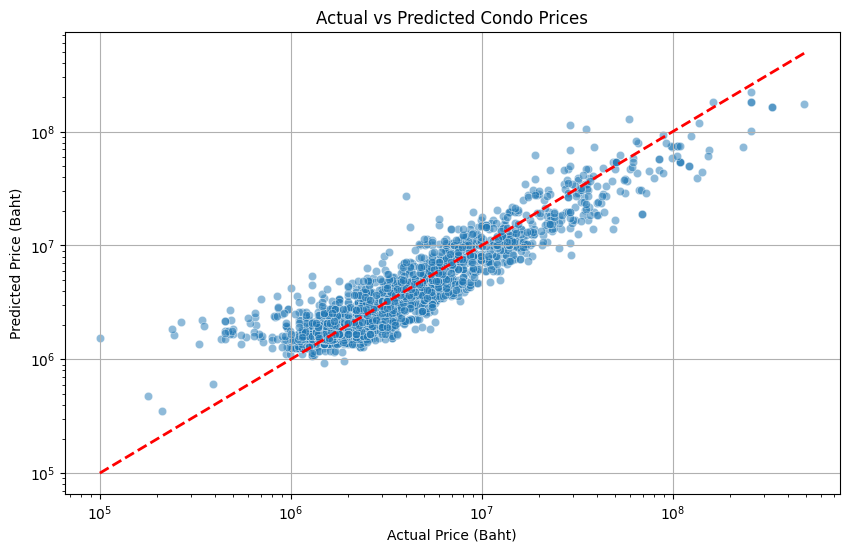

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # เรียกใช้ numpy

plt.figure(figsize=(10, 6))

# สร้าง Scatter Plot
sns.scatterplot(x=price_true, y=price_pred, alpha=0.5)

# เส้นสมมติ (Perfect Prediction)
# 💡 แก้ไข: ใช้ np.max และ np.min แทน max/min เฉยๆ
max_val = np.max([price_true.max(), price_pred.max()])
min_val = np.min([price_true.min(), price_pred.min()])

plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xlabel('Actual Price (Baht)')
plt.ylabel('Predicted Price (Baht)')
plt.title('Actual vs Predicted Condo Prices')

# ใช้ Log Scale เพื่อให้ดูกราฟง่ายขึ้น (เพราะราคาคอนโดมีความต่างกันสูงมาก)
plt.xscale('log') 
plt.yscale('log')

plt.grid(True)
plt.show()